# Retail Data Wrangling and Analytics

In [173]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Database
import os
from sqlalchemy import create_engine

# Notebook display
%matplotlib inline
sns.set_style("whitegrid")

# Load Data from PSQL into DataFrame

**Setup Docker Containers** - A bridge network called jrvs-net was created and verified so that jrvs-jupyter and jrvs-psql can communicate with each other

![](https://i.imgur.com/VQrBVBk.jpg)

**Data Load** - Use [pandas.read_sql](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_sql.html) api to load the PSQL retail table into a Pandas DataFrame

![](https://i.imgur.com/AmkAP63.jpg)


In [174]:
#install psql "driver"
!pip3 install psycopg2-binary

In [176]:
DB_USER = os.getenv("PGUSER", "postgres")
DB_PASS = os.getenv("PGPASSWORD", "password")
DB_HOST = os.getenv("PGHOST", "jrvs-psql")
DB_PORT = os.getenv("PGPORT", "5432")
DB_NAME = os.getenv("PGDATABASE", "postgres")

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

query = "SELECT * FROM retail"
retail_df = pd.read_sql(query, engine)

In [177]:
print(f"Loaded {len(retail_df):,} rows × {retail_df.shape[1]} columns")

Loaded 1,067,371 rows × 8 columns


In [179]:
# Standardize columns
retail_df.columns = retail_df.columns.str.strip().str.lower()

In [180]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   invoice_no    1067371 non-null  object        
 1   stock_code    1067371 non-null  object        
 2   description   1062989 non-null  object        
 3   quantity      1067371 non-null  int64         
 4   invoice_date  1067371 non-null  datetime64[ns]
 5   unit_price    1067371 non-null  float64       
 6   customer_id   824364 non-null   float64       
 7   country       1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


# Dataset Overview

In [181]:
# Dataset size
# Dataset is at transaction line-item level (multiple rows per invoice)
num_rows, num_cols = retail_df.shape

# Time period
start_date = retail_df['invoice_date'].min().date()
end_date = retail_df['invoice_date'].max().date()

# Memory footprint
memory_mb = retail_df.memory_usage(deep=True).sum() / (1024 ** 2)

summary_df = pd.DataFrame({
    "Metric": ["Rows", "Columns", "Start Date", "End Date", "Memory Usage (MB, deep)"],
    "Value": [num_rows, num_cols, start_date, end_date, round(memory_mb, 2)]
})

summary_df

,Metric,Value
0,Rows,1067371
1,Columns,8
2,Start Date,2009-12-01
3,End Date,2011-12-09
4,"Memory Usage (MB, deep)",316.55


# Standardisation and Deduplication

In [182]:
# Normalize key string fields (prevents undercounting cancellations, mismatched grouping)
retail_df["invoice_no"] = retail_df["invoice_no"].astype(str).str.strip()
retail_df["stock_code"] = retail_df["stock_code"].astype(str).str.strip()
retail_df["description"] = retail_df["description"].astype(str).str.strip()
retail_df["country"] = retail_df["country"].astype(str).str.strip()

# Robust cancellation flag (case-insensitive)
retail_df["is_cancelled"] = retail_df["invoice_no"].str.upper().str.startswith("C")

# Remove exact duplicate rows to prevent double-counting
rows_before = len(retail_df)
retail_df = retail_df.drop_duplicates().copy()
rows_after = len(retail_df)

print(f"Deduplication removed {rows_before - rows_after:,} rows ({(rows_before - rows_after)/rows_before*100:.2f}%). New total: {rows_after:,}")

Deduplication removed 34,335 rows (3.22%). New total: 1,033,036


# Data Quality Observations

In [154]:
num_cancellations = retail_df["is_cancelled"].sum()
cancellation_pct = round(num_cancellations / len(retail_df) * 100, 2)

num_cancellations, cancellation_pct

(19494, 1.83)

In [155]:
invalid_quantity = (retail_df["quantity"] <= 0).sum()
invalid_price = (retail_df["unit_price"] <= 0).sum()

invalid_quantity, invalid_price

(22950, 6207)

In [183]:
duplicate_count = retail_df.duplicated().sum()
duplicate_count

0

In [184]:
# Inconsistent descriptions per stock_code (exclude null descriptions so counts are meaningful)
description_variants = (
    retail_df.dropna(subset=["description"])
    .groupby("stock_code")["description"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)
description_variants

stock_code
20713     10
23084      8
22734      8
21181      8
22423      8
47566B     7
22719      7
85175      7
21830      7
23131      6
Name: description, dtype: int64

In [185]:
# Convert invoice_date to datetime
retail_df['invoice_date'] = pd.to_datetime(retail_df['invoice_date'])

In [186]:
# Separate cancellations
cancel_df = retail_df[retail_df["is_cancelled"]].copy()

In [187]:
# Filter valid sales
sales_df = retail_df[
    (~retail_df["is_cancelled"]) &
    (retail_df["quantity"] > 0) &
    (retail_df["unit_price"] > 0)
].copy()

In [188]:
# Revenue per line item (not per invoice)
sales_df["revenue"] = sales_df["quantity"] * sales_df["unit_price"]

In [189]:
non_cancel_invalid_qty = ((~retail_df["is_cancelled"]) & (retail_df["quantity"] <= 0)).sum()
print(f"Non-cancellation rows with quantity <= 0: {non_cancel_invalid_qty:,}")

Non-cancellation rows with quantity <= 0: 3,393


# Monthly Revenue Trend

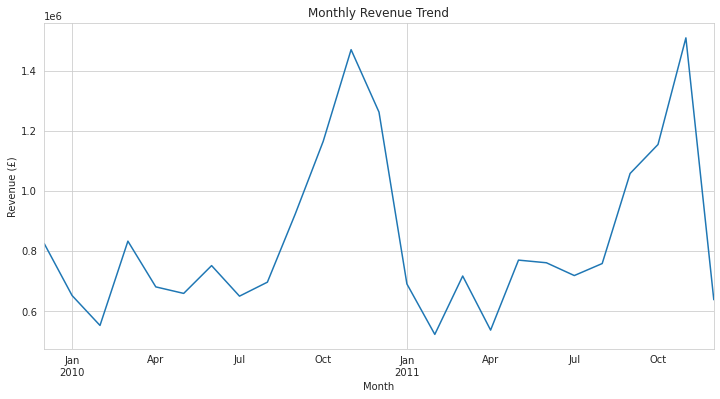

In [162]:
monthly_revenue = sales_df.resample('M', on='invoice_date')['revenue'].sum()

plt.figure(figsize=(12,6))
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.grid(True)
plt.show()

# Monthly Active Users

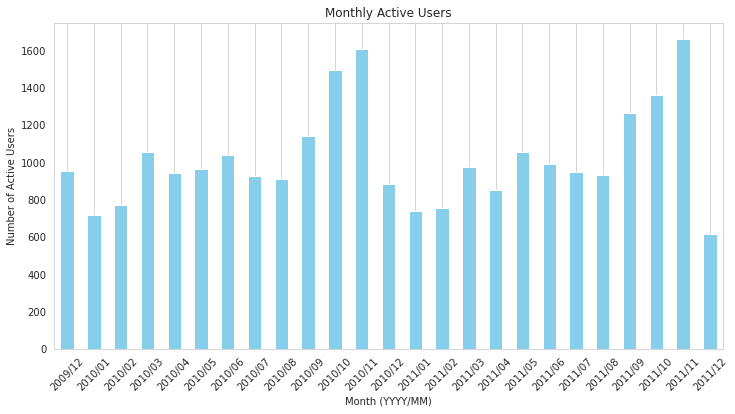

In [163]:
# Compute monthly active users
monthly_active_users = sales_df.groupby(pd.Grouper(key='invoice_date', freq='M'))['customer_id'].nunique()

# Format the index as YYYY/MM for x-axis
monthly_active_users.index = monthly_active_users.index.strftime('%Y/%m')

# Plot
plt.figure(figsize=(12,6))
monthly_active_users.plot(kind='bar', color='skyblue')
plt.title("Monthly Active Users")
plt.xlabel("Month (YYYY/MM)")
plt.ylabel("Number of Active Users")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


# New vs Existing Users

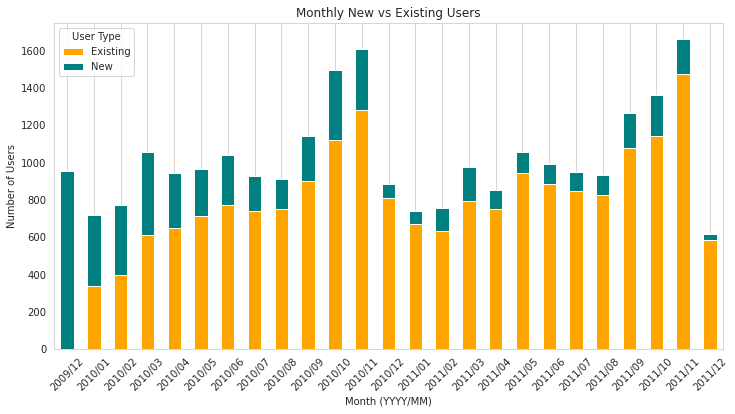

In [164]:
# Identify first purchase month for each customer
first_purchase = sales_df.groupby('customer_id')['invoice_date'].min().reset_index()
first_purchase['first_purchase_month'] = first_purchase['invoice_date'].dt.to_period('M')

# Merge first purchase month with sales_df
sales_df = sales_df.merge(first_purchase[['customer_id', 'first_purchase_month']], on='customer_id', how='left')

# Assign user type for each transaction
sales_df['user_type'] = np.where(
    sales_df['invoice_date'].dt.to_period('M') == sales_df['first_purchase_month'],
    'New',
    'Existing'
)

# Count new and existing users per month
monthly_users = sales_df.groupby([sales_df['invoice_date'].dt.to_period('M'), 'user_type'])['customer_id'].nunique().unstack(fill_value=0)

# Format index for x-axis as YYYY/MM
monthly_users.index = monthly_users.index.astype(str).str.replace('-', '/')

# Plot
monthly_users.plot(kind='bar', stacked=True, figsize=(12,6), color=['orange', 'teal'])
plt.title("Monthly New vs Existing Users")
plt.xlabel("Month (YYYY/MM)")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.legend(title='User Type')
plt.grid(axis='y')
plt.show()

# Product Analysis - Sales vs Cancellations

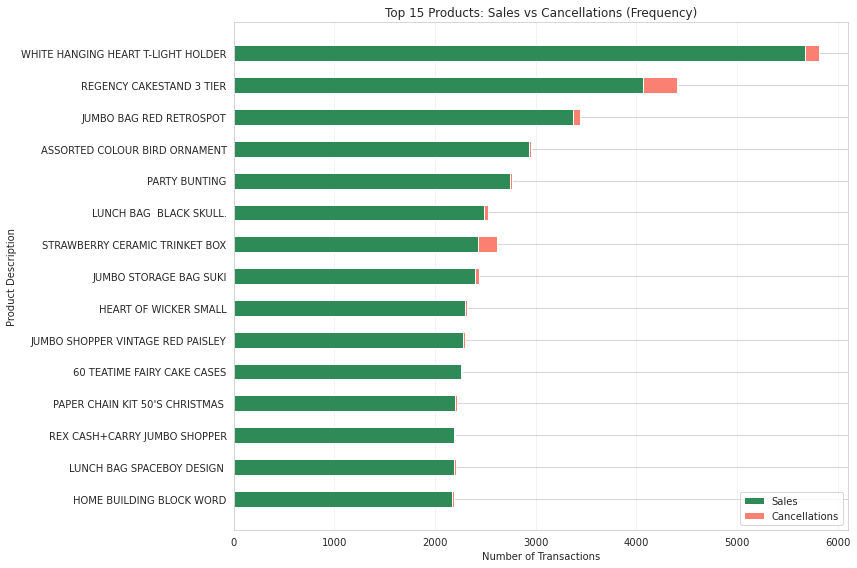

In [165]:
# -----------------------------
# 1. Clean cancellation data
# -----------------------------
cancel_df_clean = cancel_df[
    ~cancel_df['description'].isin(['Manual', 'POSTAGE', 'Discount', 'SAMPLES'])
]

# -----------------------------
# 2. Top 15 products by SALES FREQUENCY
# -----------------------------
top_selling_products = (
    sales_df
    .groupby(['stock_code', 'description'])
    .size()
    .reset_index(name='sales_count')
    .sort_values('sales_count', ascending=False)
    .head(15)
)

# -----------------------------
# 3. Cancellation frequency for same products
# -----------------------------
cancel_counts = (
    cancel_df_clean
    .groupby(['stock_code', 'description'])
    .size()
    .reset_index(name='cancel_count')
)

# -----------------------------
# 4. Merge sales & cancellations
# -----------------------------
product_summary = pd.merge(
    top_selling_products,
    cancel_counts,
    on=['stock_code', 'description'],
    how='left'
).fillna(0)

# -----------------------------
# 5. Sort for plotting
# -----------------------------
product_summary = product_summary.sort_values('sales_count')

# -----------------------------
# 6. Plot stacked bar chart
# -----------------------------
plt.figure(figsize=(12, 8))
bar_height = 0.5

plt.barh(
    product_summary['description'],
    product_summary['sales_count'],
    label='Sales',
    height = bar_height,
    color='seagreen'
)

plt.barh(
    product_summary['description'],
    product_summary['cancel_count'],
    left=product_summary['sales_count'],
    label='Cancellations',
    height = bar_height,
    color='salmon'
)

# -----------------------------
# 7. Formatting
# -----------------------------
plt.title("Top 15 Products: Sales vs Cancellations (Frequency)")
plt.xlabel("Number of Transactions")
plt.ylabel("Product Description")
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Cancellation Risk vs Revenue Impact

In [166]:
# -----------------------------
# Prepare cancellation revenue
# -----------------------------
cancel_df_clean['lost_revenue'] = abs(cancel_df_clean['quantity']) * cancel_df_clean['unit_price']

# -----------------------------
# Monthly cancellations
# -----------------------------
monthly_cancel = cancel_df_clean.groupby(
    pd.Grouper(key='invoice_date', freq='M')
).agg(
    cancelled_orders=('invoice_no', 'nunique'),
    lost_revenue=('lost_revenue', 'sum')
)

# -----------------------------
# Monthly total orders & revenue
# -----------------------------
monthly_total = sales_df.groupby(
    pd.Grouper(key='invoice_date', freq='M')
).agg(
    total_orders=('invoice_no', 'nunique'),
    total_revenue=('revenue', 'sum')
)

# -----------------------------
# Combine
# -----------------------------
monthly_cancel_analysis = monthly_total.merge(
    monthly_cancel,
    left_index=True,
    right_index=True,
    how='left'
).fillna(0)

# -----------------------------
# Cancellation rate (%)
# -----------------------------
monthly_cancel_analysis['cancel_rate_pct'] = (
    monthly_cancel_analysis['cancelled_orders'] /
    monthly_cancel_analysis['total_orders']
) * 100


<ipython-input-166-62fed9496f94>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cancel_df_clean['lost_revenue'] = abs(cancel_df_clean['quantity']) * cancel_df_clean['unit_price']


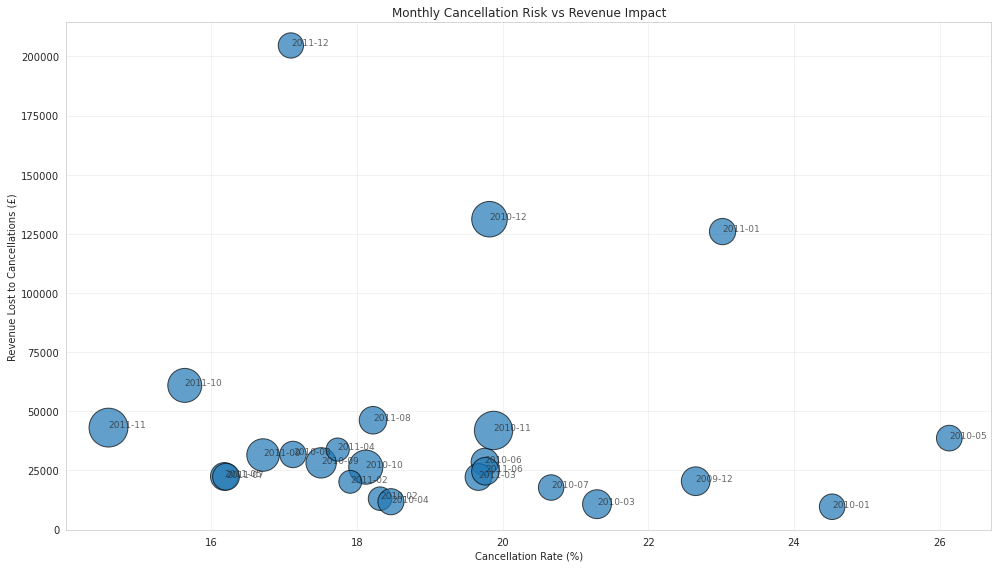

In [167]:
plt.figure(figsize=(14,8))

plt.scatter(
    monthly_cancel_analysis['cancel_rate_pct'],
    monthly_cancel_analysis['lost_revenue'],
    s=monthly_cancel_analysis['total_revenue'] / 1000,  # scale bubbles
    alpha=0.7,
    edgecolors='black'
)

# Annotate months
for date, row in monthly_cancel_analysis.iterrows():
    plt.text(
        row['cancel_rate_pct'],
        row['lost_revenue'],
        date.strftime('%Y-%m'),
        fontsize=9,
        alpha=0.7
    )

plt.xlabel("Cancellation Rate (%)")
plt.ylabel("Revenue Lost to Cancellations (£)")
plt.title("Monthly Cancellation Risk vs Revenue Impact")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Share of Revenue Lost

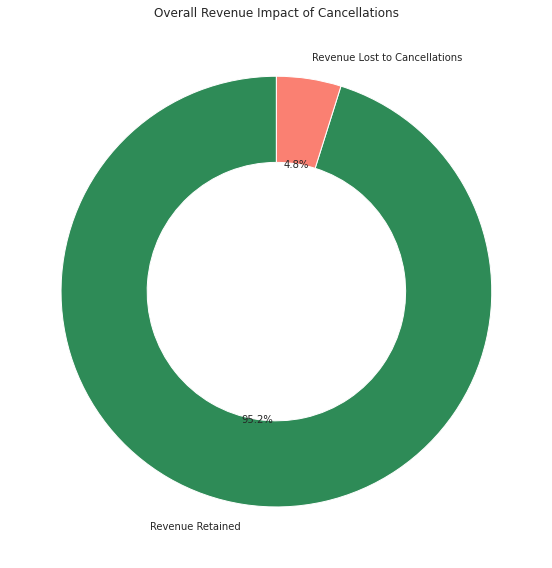

In [168]:
lost = monthly_cancel_analysis['lost_revenue'].sum()
retained = monthly_cancel_analysis['total_revenue'].sum()

plt.figure(figsize=(8,8))

plt.pie(
    [retained, lost],
    labels=['Revenue Retained', 'Revenue Lost to Cancellations'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['seagreen', 'salmon'],
    wedgeprops={'width': 0.4}
)

plt.title("Overall Revenue Impact of Cancellations")
plt.tight_layout()
plt.show()

# Revenue by Country (Geography Analysis)

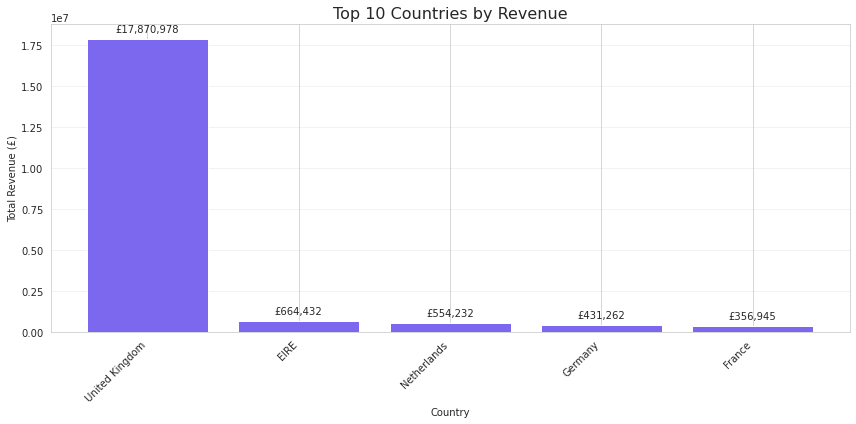

In [169]:
# -----------------------------
# Revenue by Country (Top 10)
# -----------------------------
country_revenue = sales_df.groupby('country')['revenue'].sum().sort_values(ascending=False)
top_countries = country_revenue.head(5)  # Focus on top 10 countries

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12,6))
bars = plt.bar(top_countries.index, top_countries.values, color='mediumslateblue')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.annotate(
        f'£{height:,.0f}', 
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),  # Offset label a bit above the bar
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=10
    )

# Titles and labels
plt.title("Top 10 Countries by Revenue", fontsize=16)
plt.xlabel("Country")
plt.ylabel("Total Revenue (£)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# Average Order Value (AOV) - Monthly

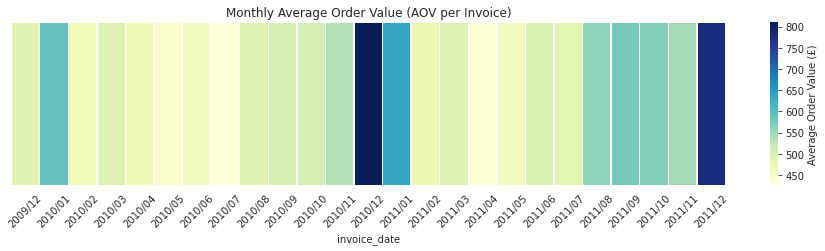

In [170]:
# 1) Build invoice-level totals (one row per invoice)
invoice_df = sales_df.groupby('invoice_no').agg(
    invoice_revenue=('revenue', 'sum'),
    invoice_date=('invoice_date', 'first')   # use first (or min) invoice timestamp
).reset_index()

# 2) Monthly AOV per invoice
monthly_aov = invoice_df.resample('M', on='invoice_date')['invoice_revenue'].mean()

# 3) Convert to DataFrame for heatmap layout
monthly_aov_df = monthly_aov.to_frame().T
monthly_aov_df.columns = monthly_aov_df.columns.strftime('%Y/%m')

# 4) Plot clean heatmap (no numbers)
plt.figure(figsize=(16,3))
sns.heatmap(
    monthly_aov_df,
    cmap='YlGnBu',
    cbar_kws={'label': 'Average Order Value (£)'},
    annot=False,
    linewidths=0.5,
    linecolor='white'
)
plt.title("Monthly Average Order Value (AOV per Invoice)")
plt.yticks([])       # hide the single row label
plt.xticks(rotation=45)
plt.show()